In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import periodogram
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv (
    "teste/dados_sabesp_cantareira_historico.csv", sep=';', parse_dates=['Data'], dayfirst=True
)

In [4]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [5]:
dfv = df[['Data', 'Volume Útil Armazenado (%)']].copy()
dfv = dfv.rename(columns= {'Volume Útil Armazenado (%)':'Volume_util'})
dfv['Data'] = pd.to_datetime(dfv['Data'])
dfv = dfv.set_index('Data')
dfv.head()

,Volume_util
Data,
2000-01-01,"47,11254"
2000-01-02,"47,77519"
2000-01-03,"48,59438"
2000-01-04,"49,9968"
2000-01-05,"51,94578"


In [6]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Volume_util  9412 non-null   object
dtypes: object(1)
memory usage: 147.1+ KB


In [7]:
dfv['Volume_util'] = dfv['Volume_util'].str.strip()
dfv['Volume_util'] = dfv['Volume_util'].str.replace(',','.', regex=False)
dfv['Volume_util'] = pd.to_numeric(dfv['Volume_util'])

In [8]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
dtypes: float64(1)
memory usage: 147.1 KB


In [9]:
dfv['Time'] = np.arange(len(dfv.index))
dfv.head()

,Volume_util,Time
Data,,
2000-01-01,47.11254,0
2000-01-02,47.77519,1
2000-01-03,48.59438,2
2000-01-04,49.99680,3
2000-01-05,51.94578,4


In [10]:
df_periodo = dfv.loc['2016-01-01':'2025-12-31'].copy()

### Tendência da série temporal do volume útil do sistema cantareira

#### Tendência com a regressão linear

In [13]:
X = df_periodo.loc[:, ['Time']]
y = df_periodo.loc[:, ['Volume_util']]

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X).flatten(), index=X.index)
df_periodo['y_pred'] = y_pred

Text(0, 0.5, 'Volume_util')

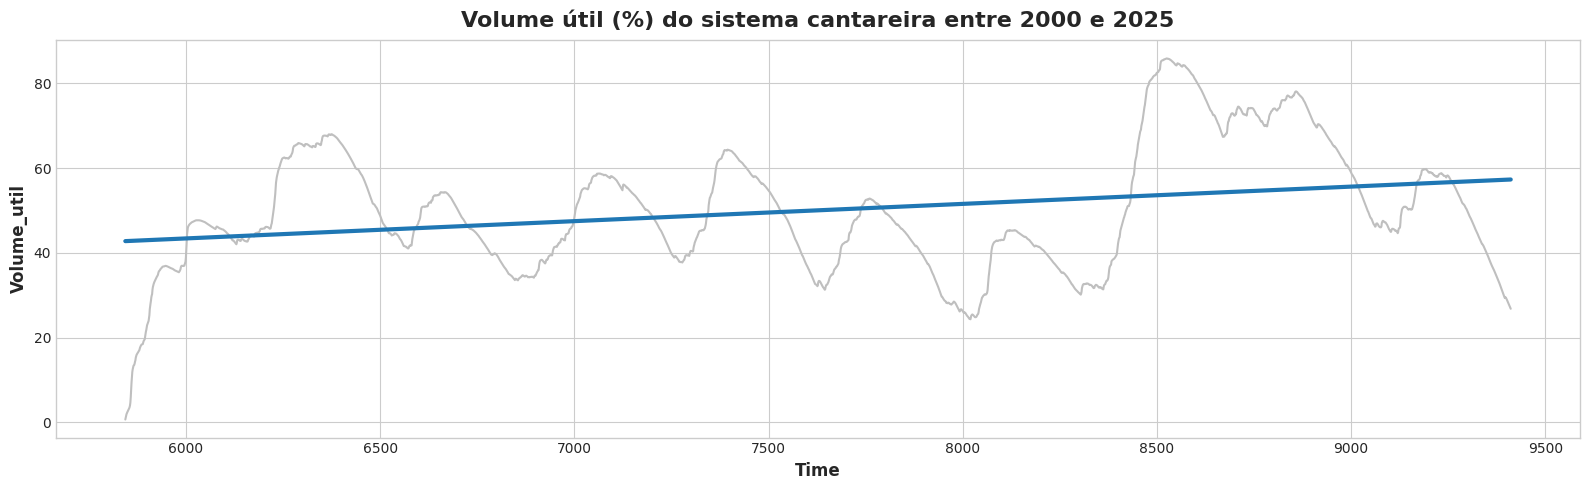

In [14]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rc(

    "figure",
    autolayout = True, 
    figsize = (11,4),
    titlesize = 18,
    titleweight = 'bold',

)

plt.rc(
    "axes",
    labelweight = 'bold',
    labelsize = "large",
    titleweight = "bold",
    titlesize = 16,
    titlepad = 10
    )

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(df_periodo['Time'], df_periodo['Volume_util'], data=df_periodo, color= '0.75')
ax.plot (df_periodo['Time'], df_periodo['y_pred'], color='tab:blue', linewidth=3, label='Regressão Linear', zorder=3)

ax.set_title('Volume útil (%) do sistema cantareira entre 2000 e 2025')
ax.set_xlabel('Time')
ax.set_ylabel('Volume_util')

#### Visualizando a tendência por médias móveis

<Axes: title={'center': 'Volume útil do sistema cantareira em médias móveis'}, xlabel='Data'>

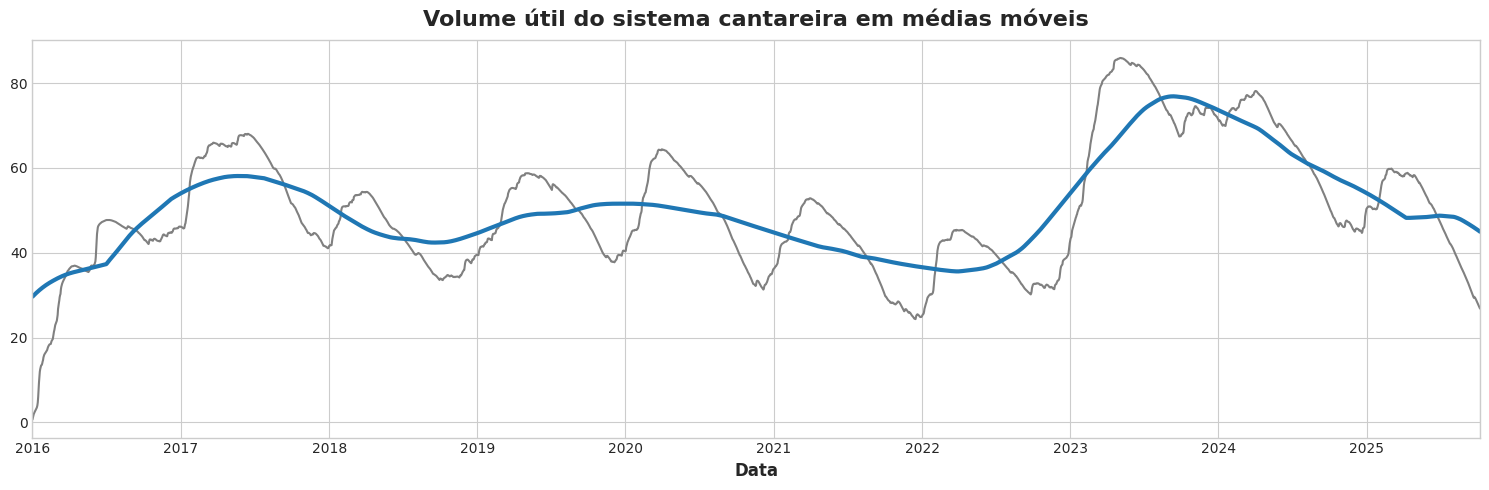

In [15]:
moving_average = df_periodo['Volume_util'].rolling(
    window = 365, 
    center = True, 
    min_periods = 182, 

).mean()

ax = df_periodo['Volume_util'].plot (style="-", color="0.5", figsize=(15,5))
moving_average.plot(
    ax=ax, linewidth=3, title = "Volume útil do sistema cantareira em médias móveis", legend=False
)

#### Tendência + Sazonalidade usando termos de Fourier 

In [16]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

%config InlineBackend.figure_format = 'retina'

def seasonal_plot (X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors = X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )

    return ax 

def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs=pd.Timedelta("365D") / pd.Timedelta("1D")
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

/tmp/ipykernel_91869/3960733576.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(


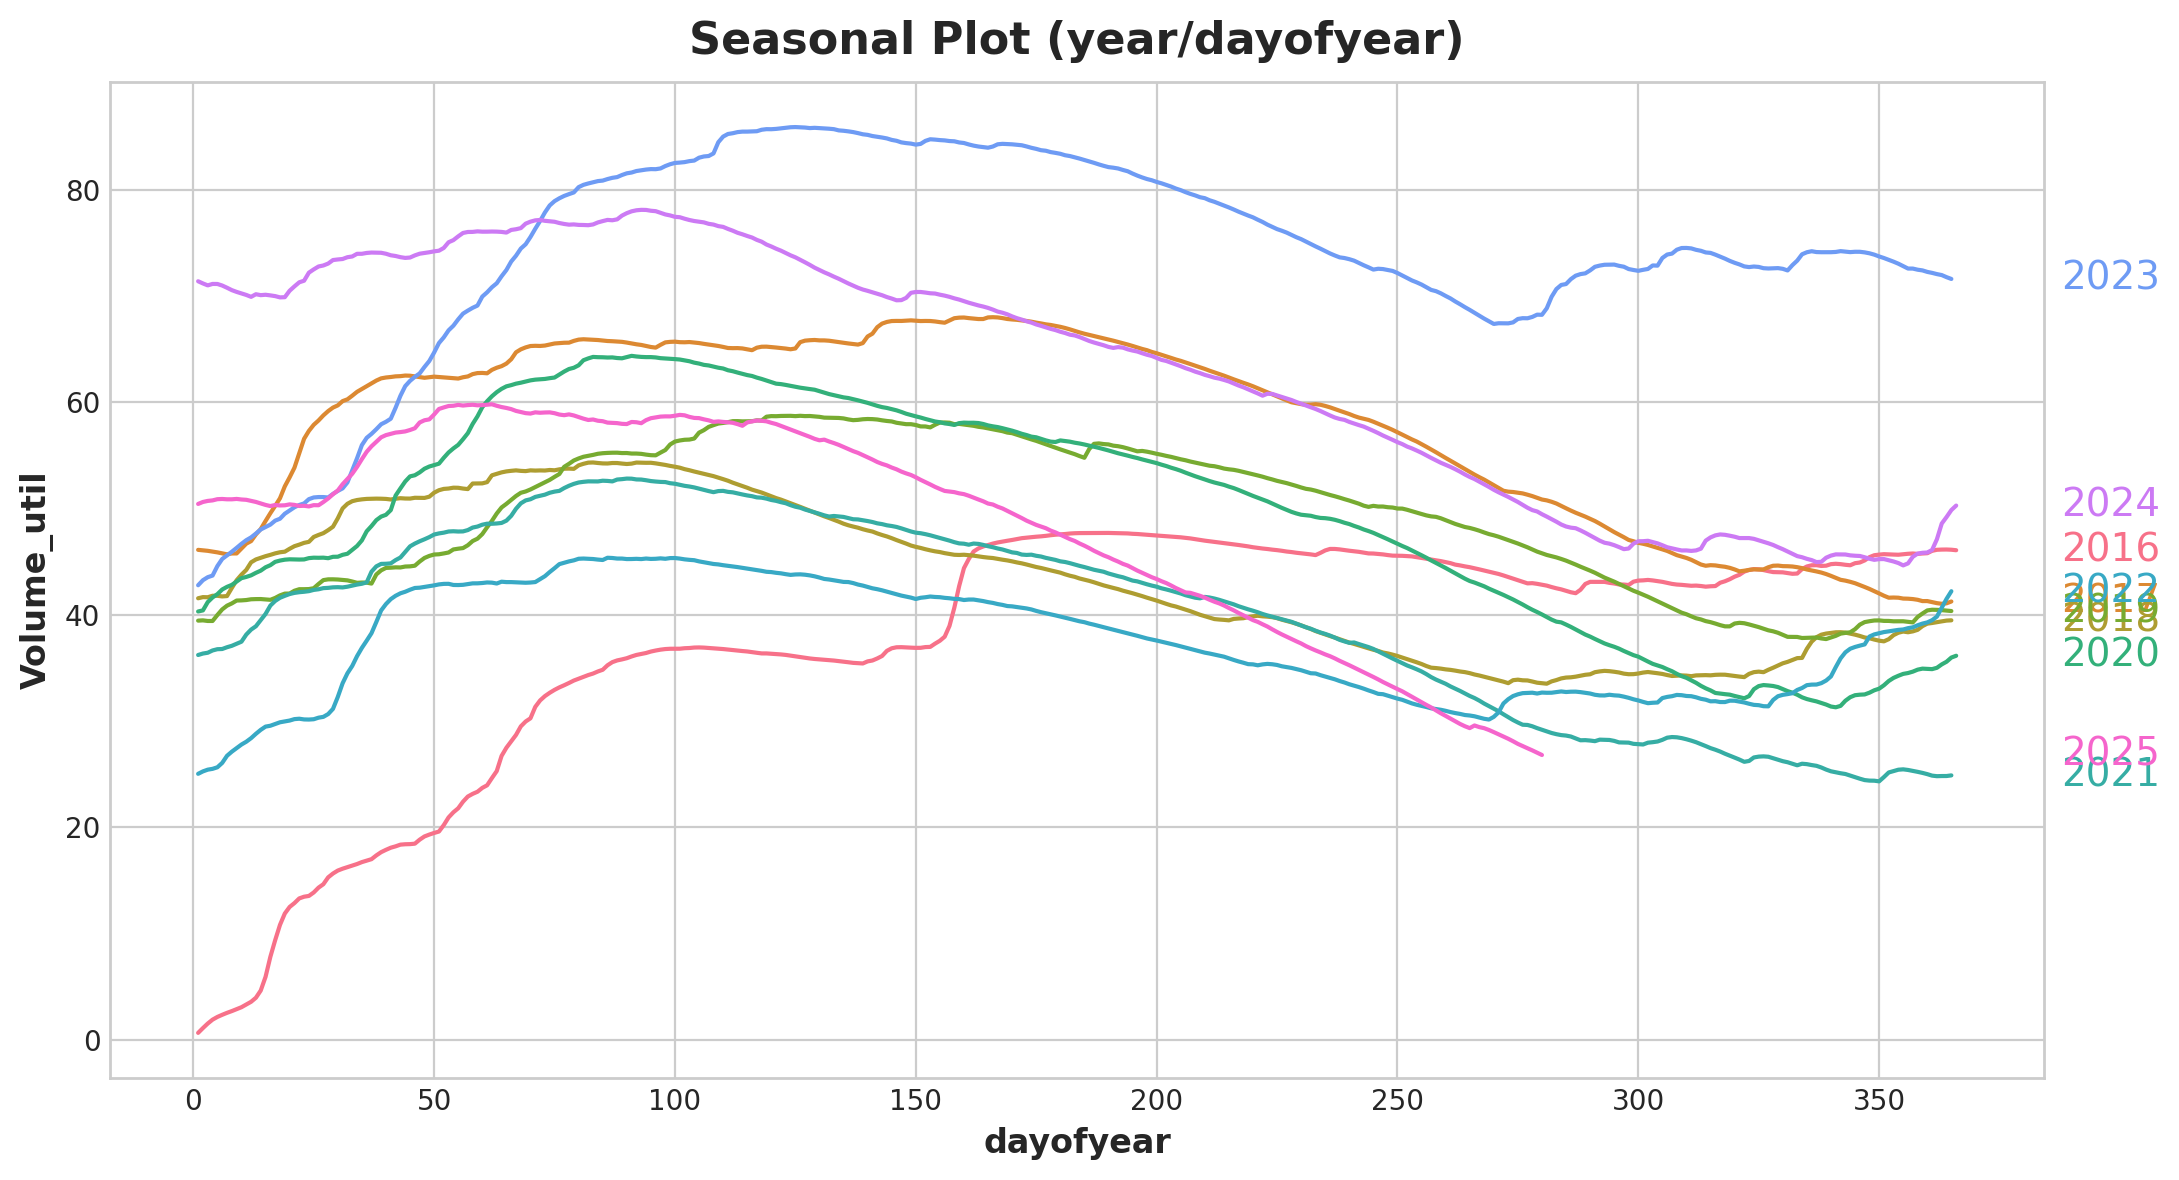

In [17]:
df_saz = df_periodo.copy()

df_saz['dayofyear'] = df_saz.index.dayofyear
df_saz['year'] = df_saz.index.year
fig, ax = plt.subplots(figsize=(11, 6))
seasonal_plot(df_saz, y="Volume_util", period="year", freq="dayofyear", ax=ax);

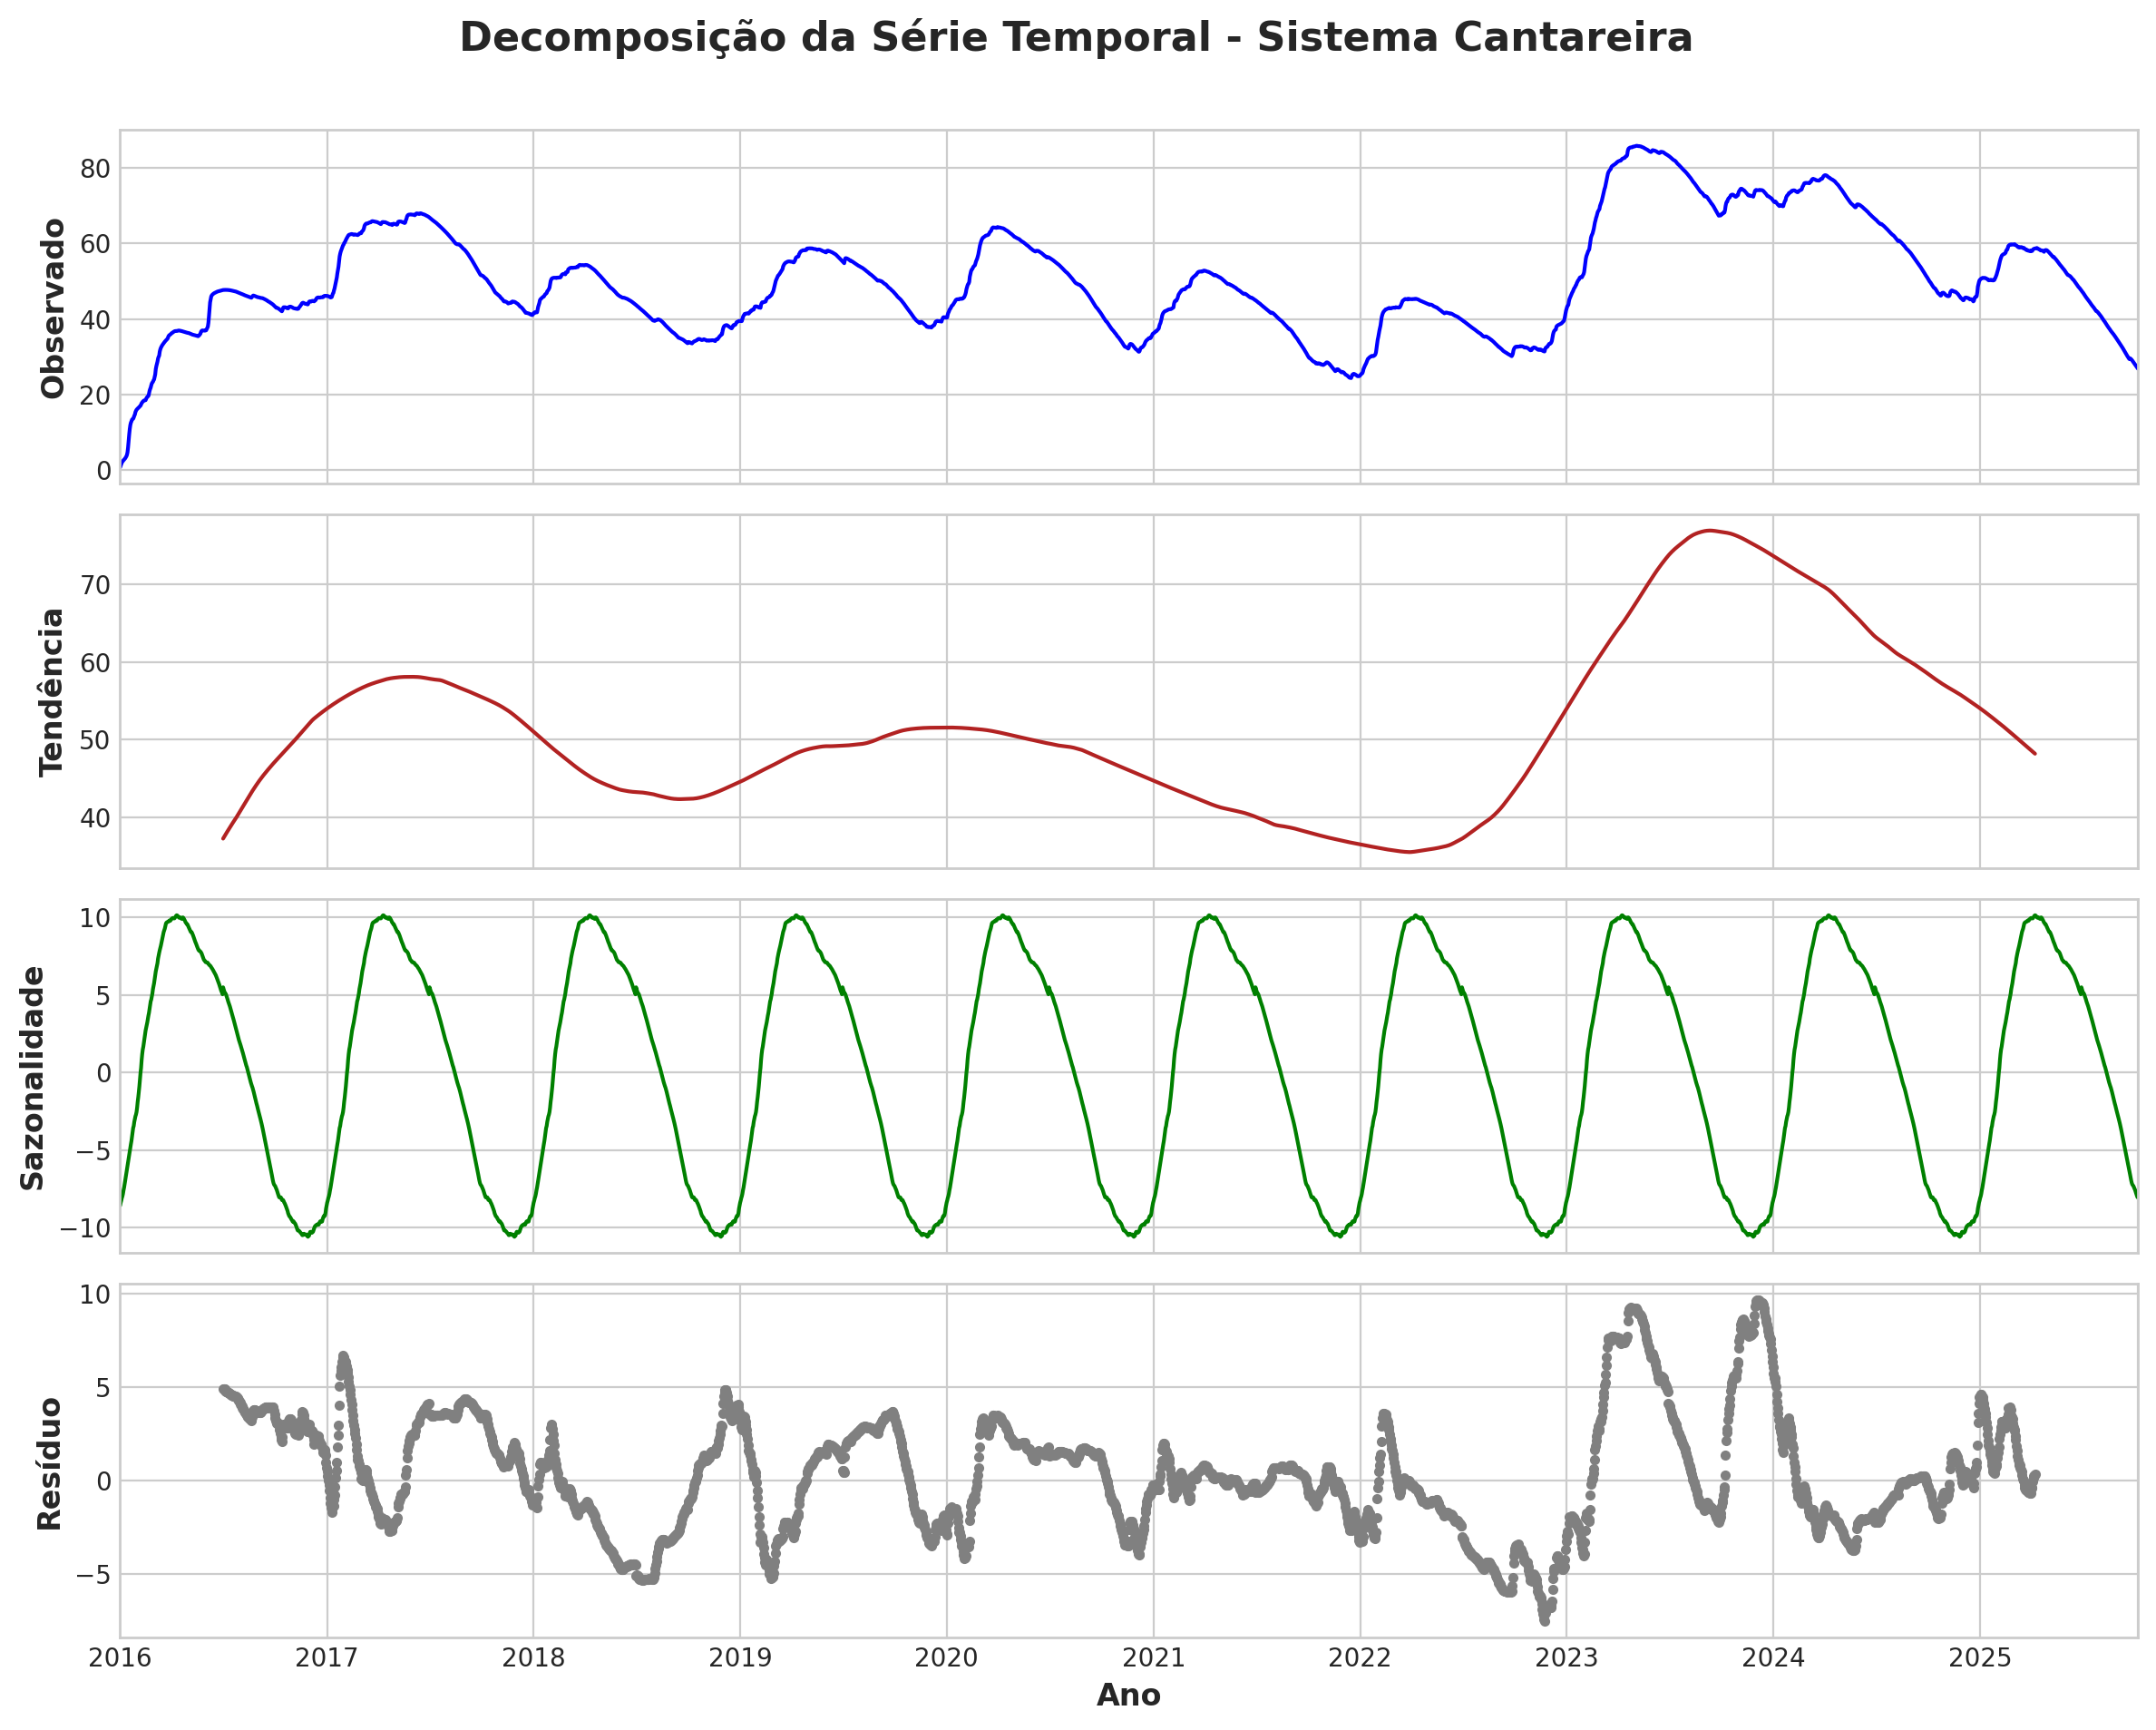

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(df_periodo['Volume_util'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

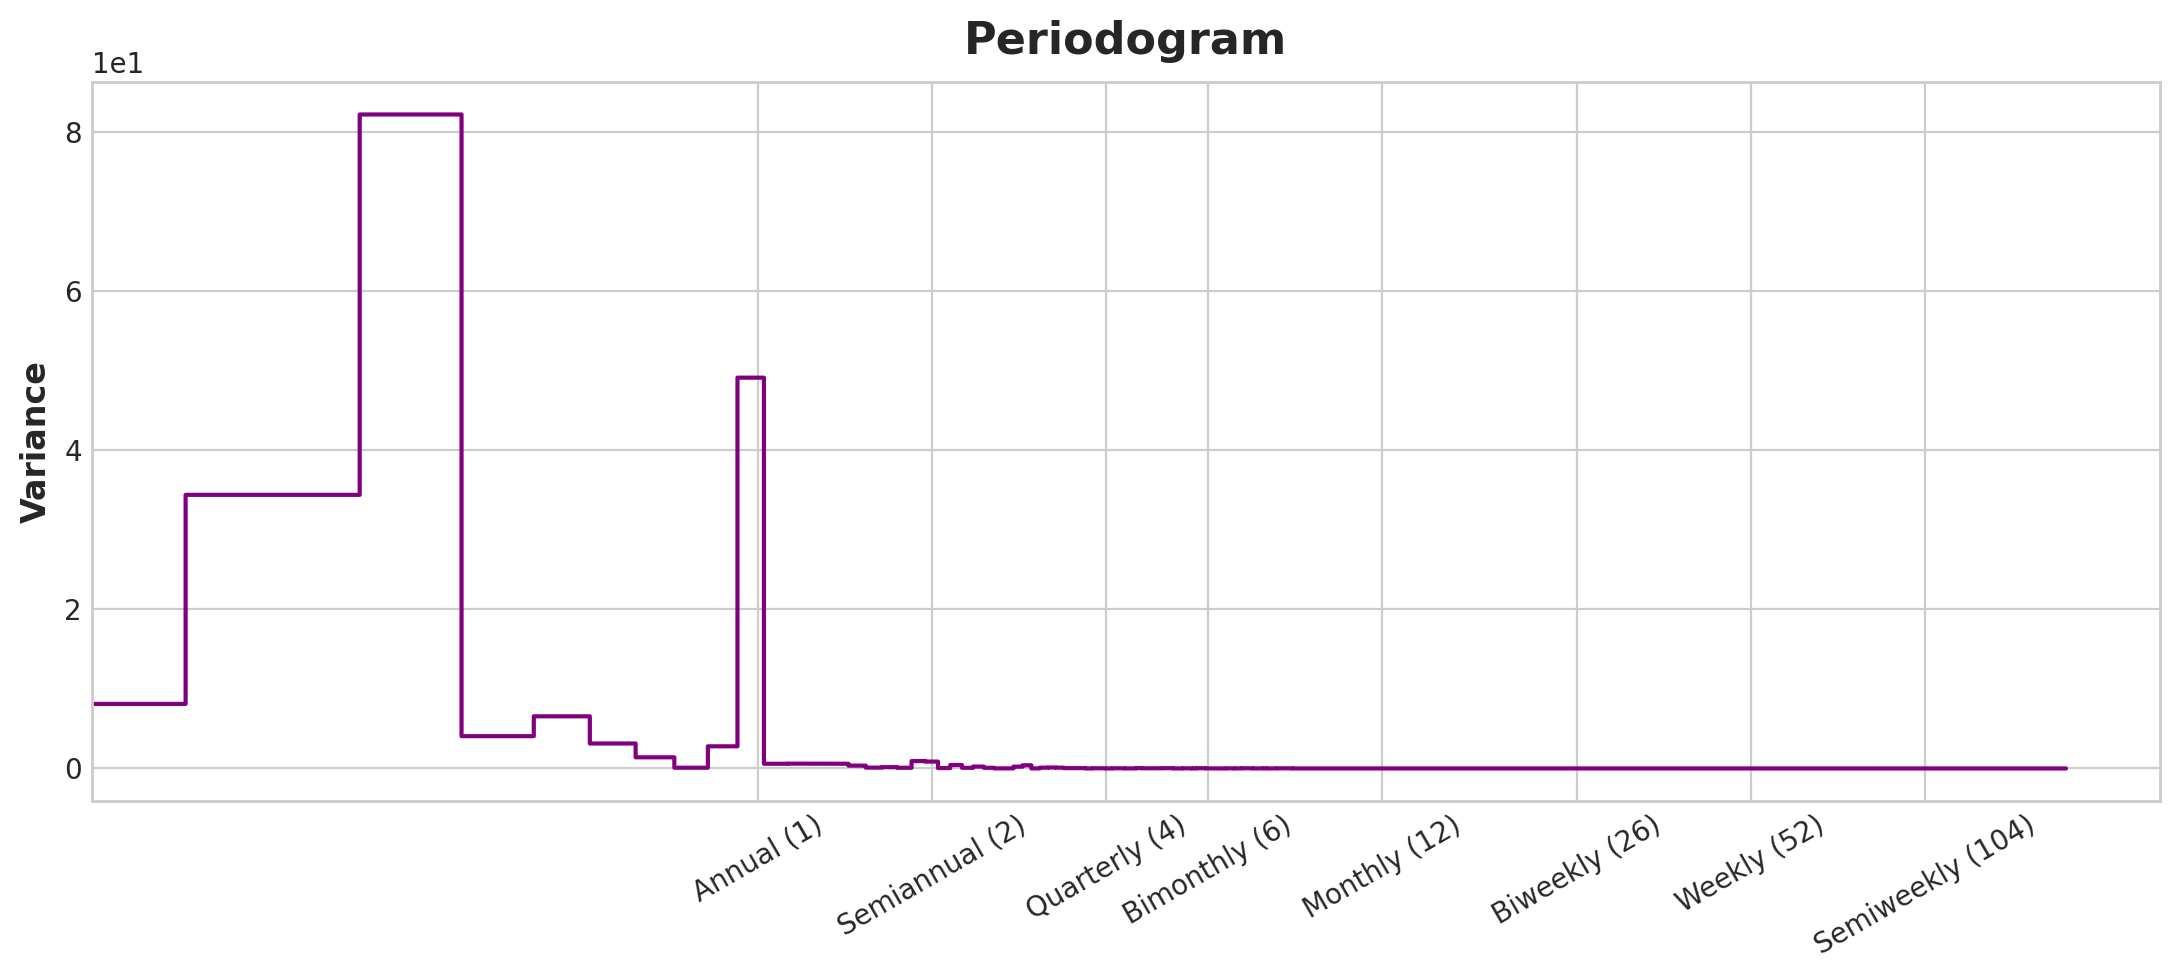

In [20]:
plot_periodogram(df_periodo.Volume_util);

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style="-.",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig


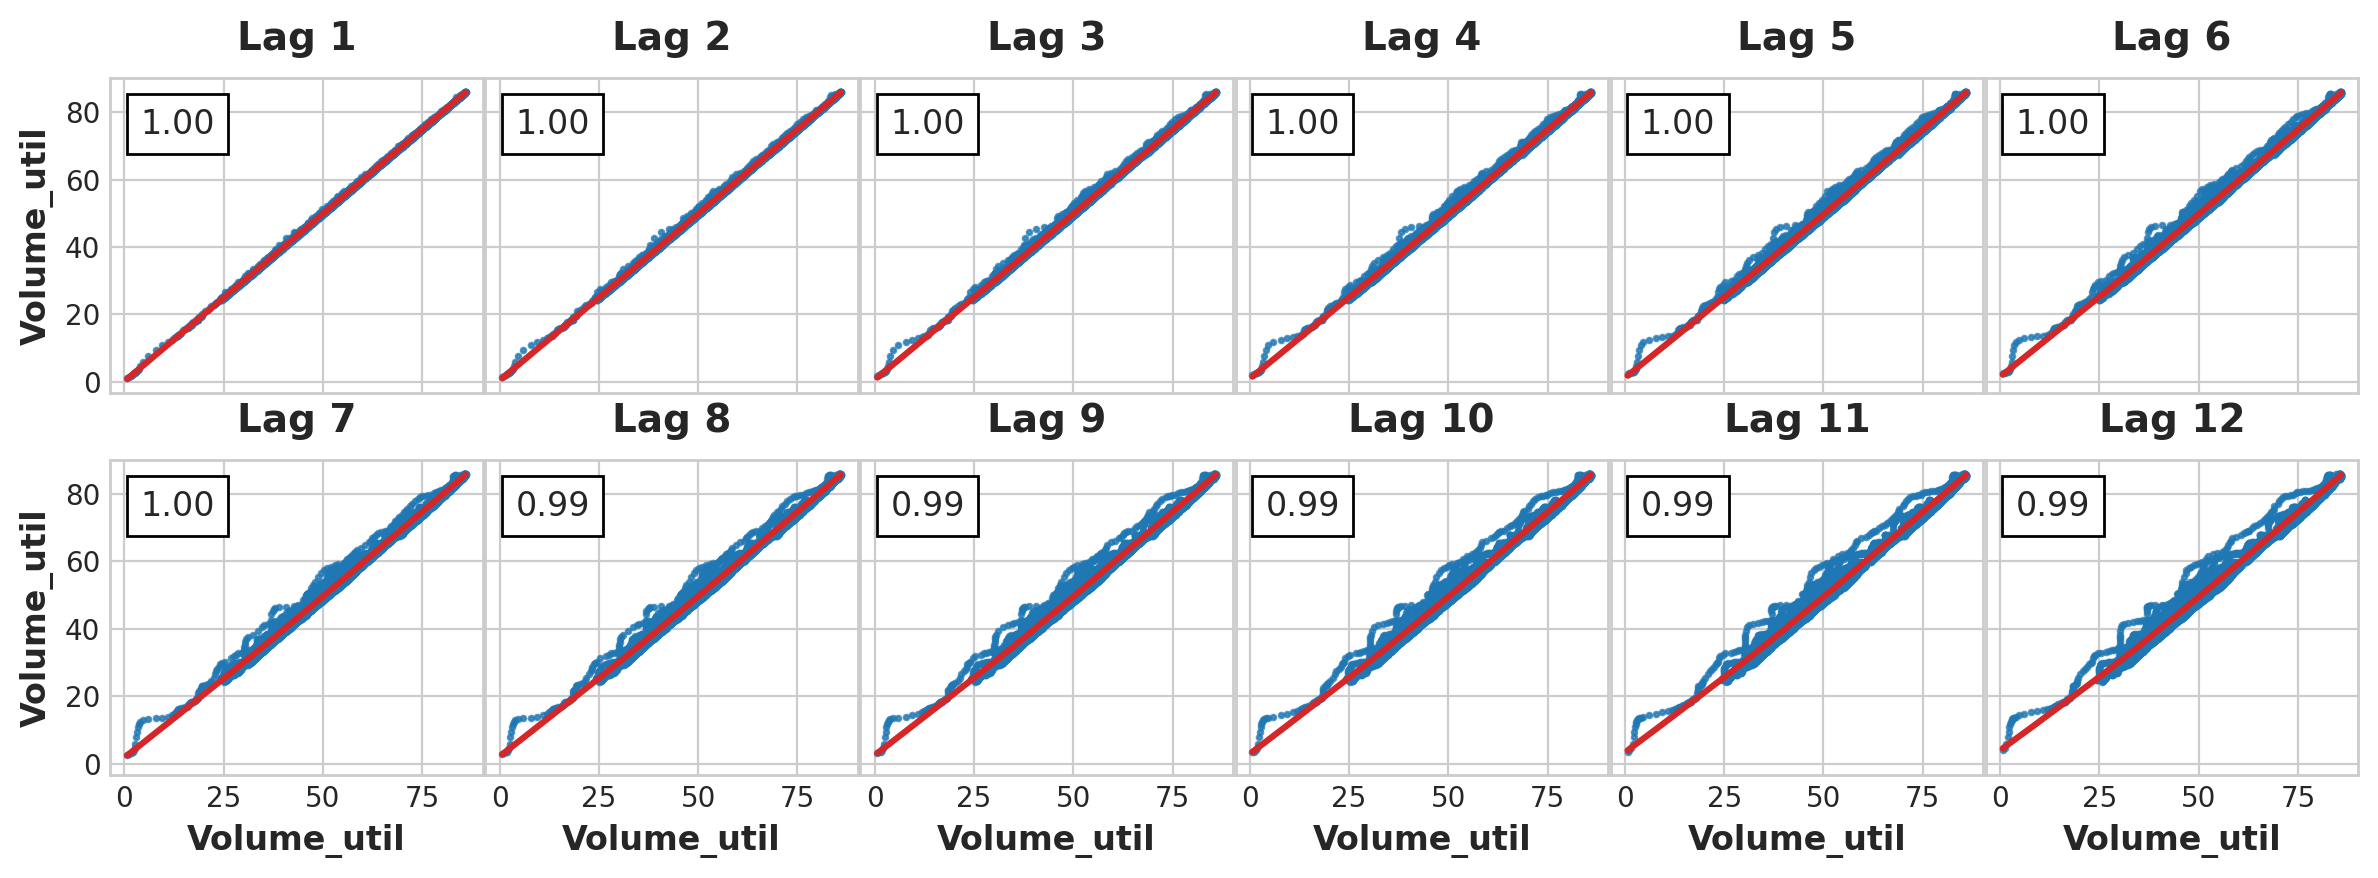

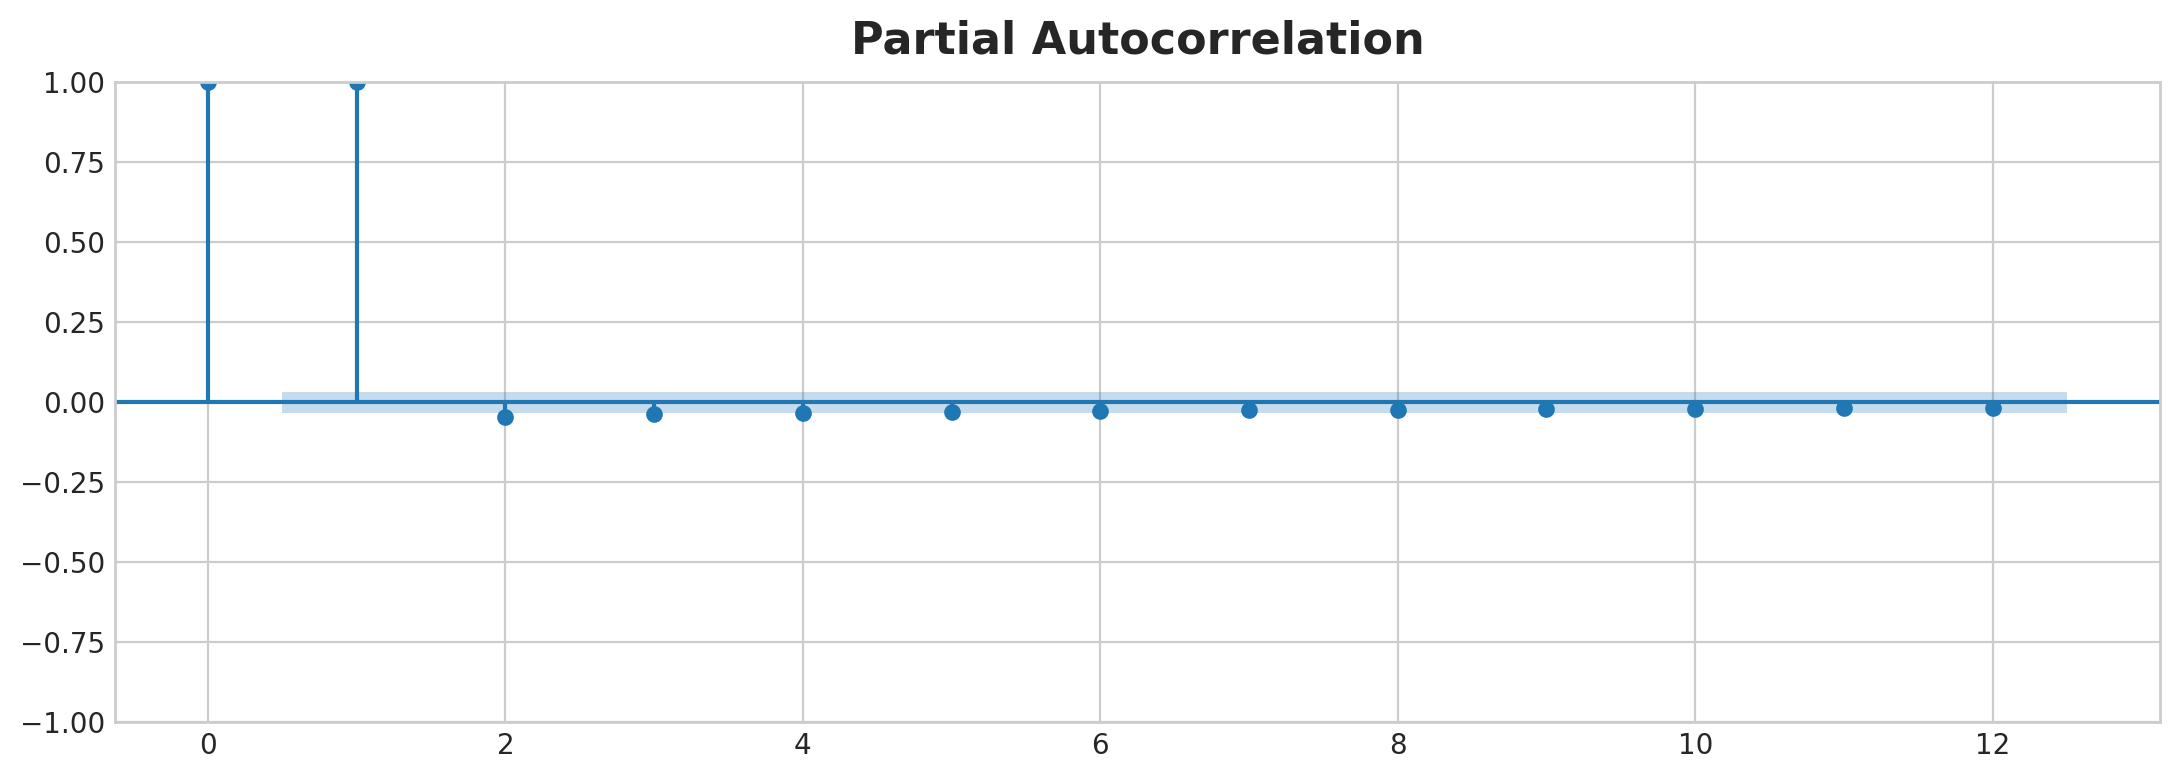

In [22]:
_ = plot_lags(df_periodo.Volume_util, lags=12, nrows=2)
_ = plot_pacf(df_periodo.Volume_util, lags=12)

#### Considerando apenas o periodo entre 2016 e 2023

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


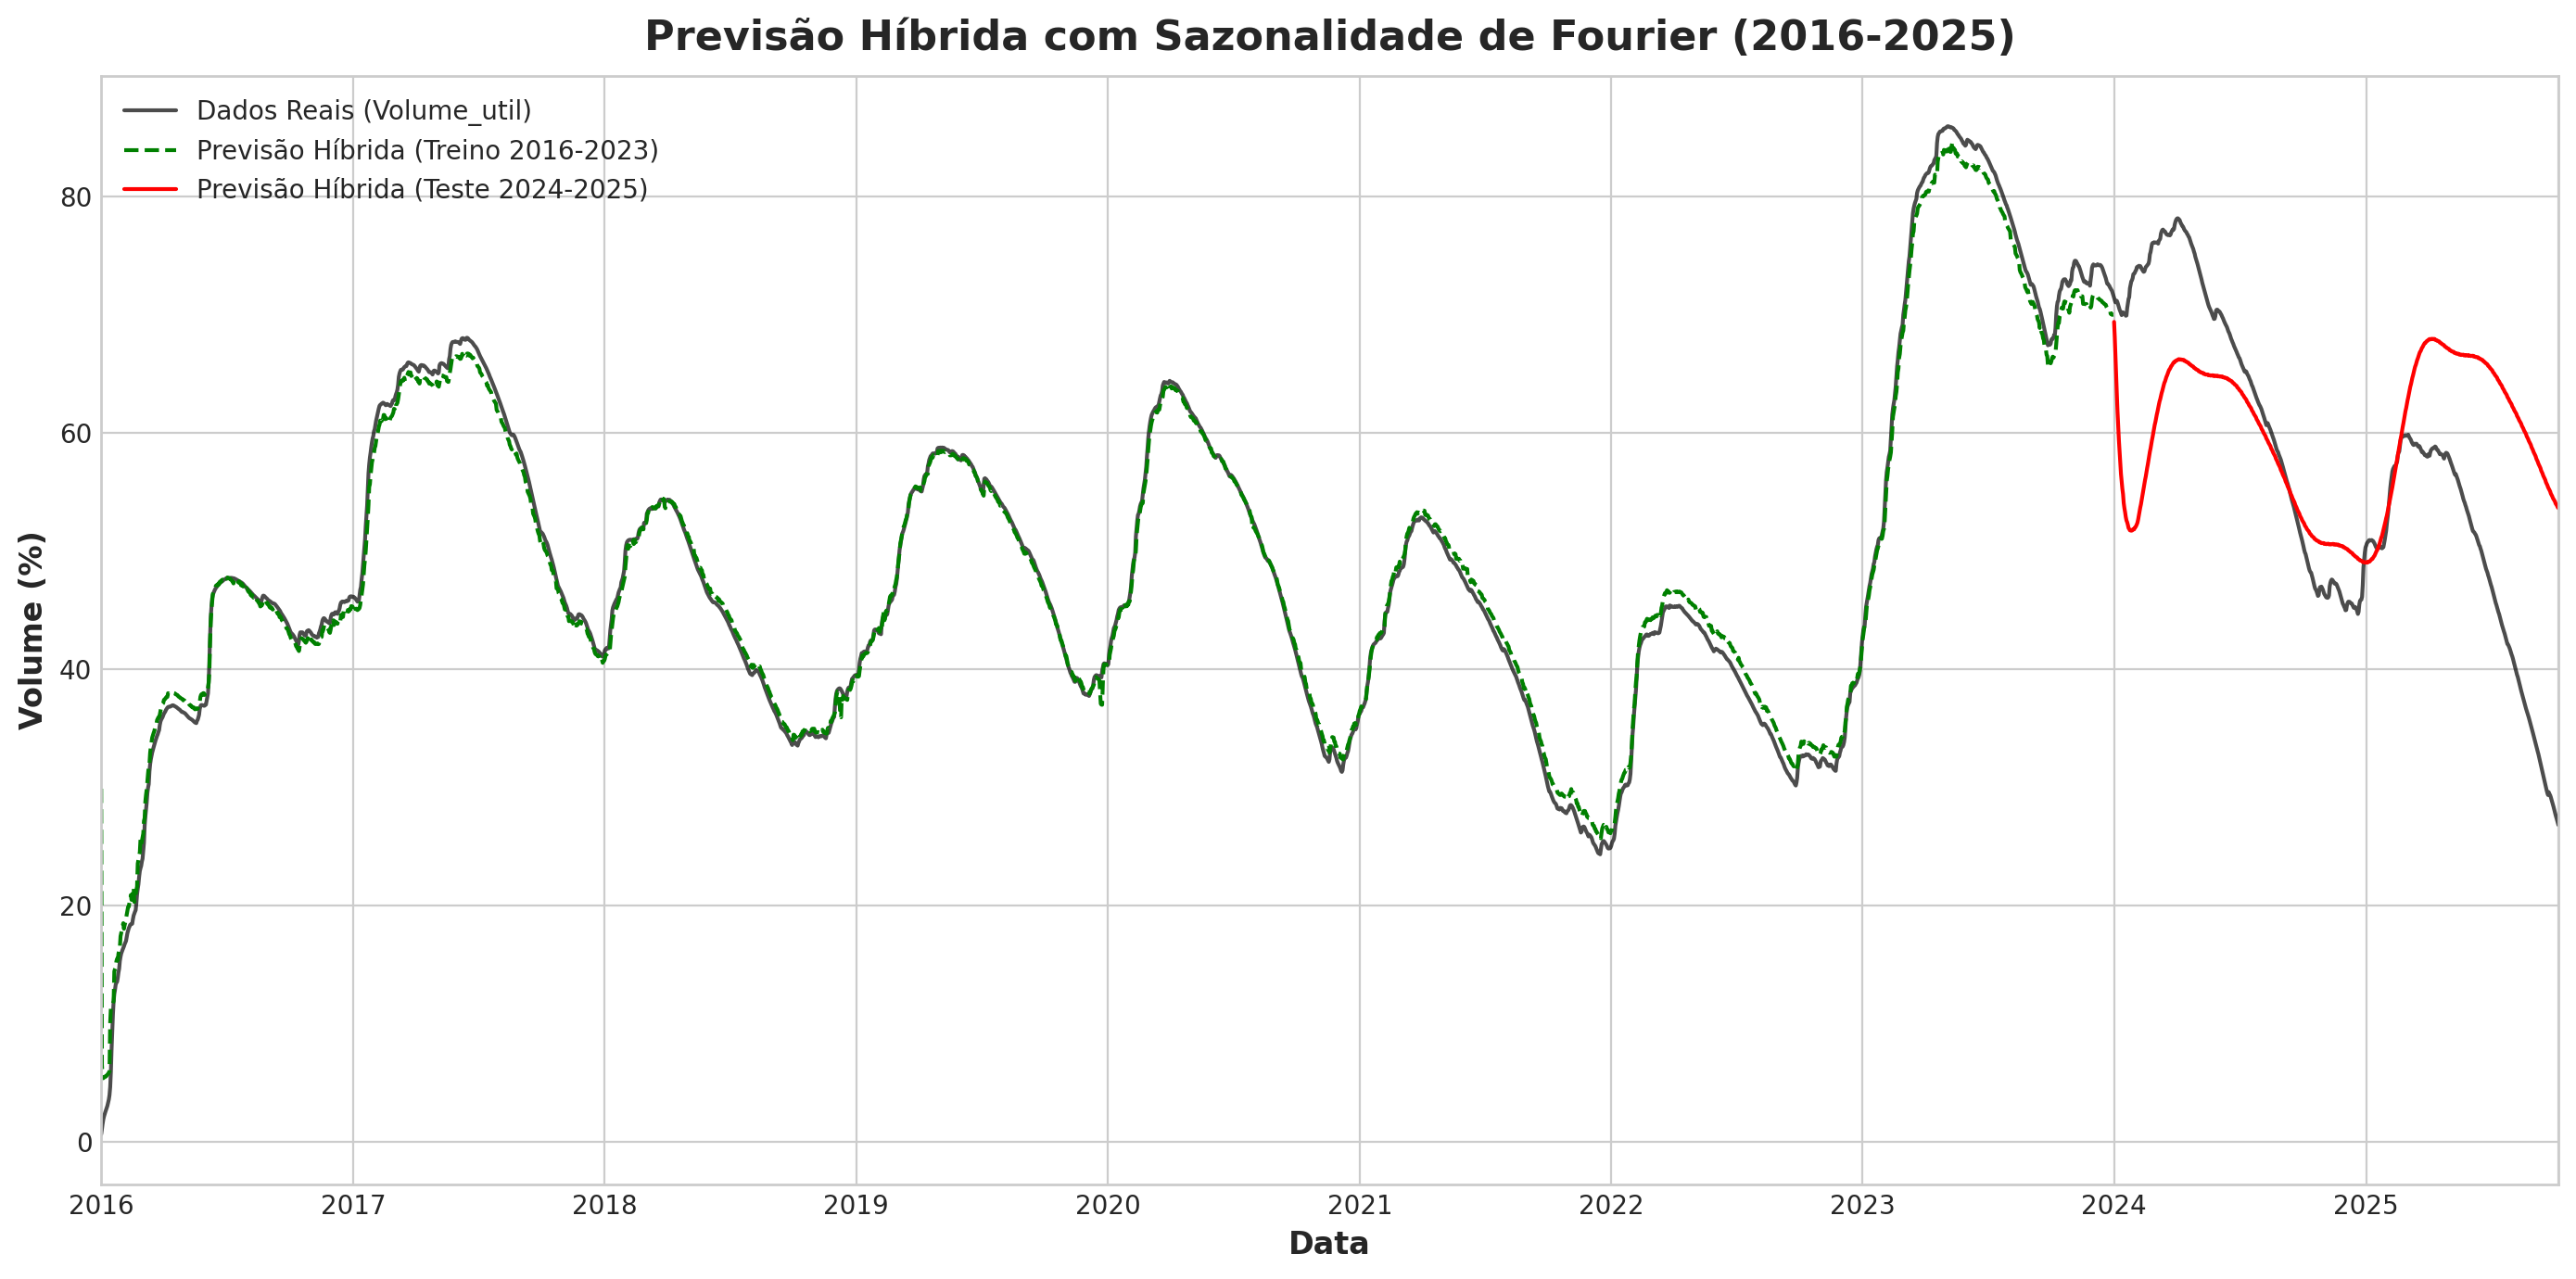

In [ ]:


# --- 1. Preparação de Dados com o Novo DeterministicProcess ---

# Garantir que o DataFrame tenha frequência diária, preenchendo datas ausentes
# Se seus dados já são diários e completos, esta linha não mudará nada.
dfv = dfv.asfreq('D')

# Filtrar para o período de interesse (2016-2025)
df_periodo = dfv.loc['2016-01-01':'2025-12-31'].copy()

# A série alvo. Se `asfreq` criou NaNs, é uma boa ideia preenchê-los.
# Ex: y1 = df_periodo["Volume_util"].interpolate(method='linear')
y1 = df_periodo["Volume_util"]

# SEU CÓDIGO INTEGRADO AQUI:
# Usando DeterministicProcess com tendência cúbica e sazonalidade de Fourier
fourier = CalendarFourier(freq="A", order=4)
dp = DeterministicProcess(
    index=y1.index,
    constant=True,               # Intercepto
    order=1,                     # Tendência cúbica
    seasonal=True,               # Sazonalidade semanal (dummy DOW)
    additional_terms=[fourier],  # Sazonalidade anual (Fourier)
    drop=True, 
)
x1 = dp.in_sample()

# Nova data de corte para a divisão treino/teste
split_date = '2024-01-01'

# Divisão das features (X) e do alvo (y) para o Modelo 1
X_train = x1.loc[x1.index < split_date]
X_test = x1.loc[x1.index >= split_date]

y_train = y1.loc[y1.index < split_date]
y_test = y1.loc[y1.index >= split_date]

# --- 2. Modelo 1: Regressão Linear (Tendência + Sazonalidade) ---

model1 = LinearRegression()
model1.fit(X_train, y_train)

# Previsões da tendência+sazonalidade para treino e teste
y_pred_train = pd.Series(model1.predict(X_train), index=X_train.index)
y_pred_test = pd.Series(model1.predict(X_test), index=X_test.index)

# --- 3. Calcular Resíduos e Preparar Dados para o Modelo 2 ---

y_res_train = y_train - y_pred_train 
y_res_test = y_test - y_pred_test
y_res = pd.concat([y_res_train, y_res_test])

def make_lags(ts, lags):
    return pd.concat(
        {f'y_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

x2 = make_lags(y_res, lags=2)
x2 = x2.fillna(0.0)

X2_train = x2.loc[x2.index < split_date]
X2_test = x2.loc[x2.index >= split_date]

# --- 4. Modelo 2: XGBoost para os Resíduos ---

model2 = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0) 
model2.fit(X2_train, y_res_train)

y_pred_res_train = pd.Series(model2.predict(X2_train), index=X2_train.index)

X2_test_recursive = X2_test.copy()
y_pred_res_test_list = []

# Loop através de cada passo de tempo no conjunto de teste
for index in X2_test.index:
    # Pegar a linha de features para o dia atual
    features_hoje = X2_test_recursive.loc[[index]]
    
    # Fazer a previsão para o dia de hoje
    pred_hoje = model2.predict(features_hoje)[0]
    
    # Armazenar a previsão
    y_pred_res_test_list.append(pred_hoje)
    
    # ATUALIZAR AS FEATURES PARA O DIA SEGUINTE
    # Encontrar o próximo índice na série temporal
    try:
        proximo_index = X2_test_recursive.index[X2_test_recursive.index.get_loc(index) + 1]
    except IndexError:
        # Chegou ao final do loop
        break
        
    # Atualizar o lag_1 do próximo dia com a PREVISÃO de hoje
    X2_test_recursive.loc[proximo_index, 'y_lag_1'] = pred_hoje
    
    # Atualizar o lag_2 do próximo dia (se existir) com o lag_1 de hoje
    if 'y_lag_2' in X2_test_recursive.columns:
        X2_test_recursive.loc[proximo_index, 'y_lag_2'] = features_hoje['y_lag_1'].values[0]

# Converter a lista de previsões em uma Série do Pandas
y_pred_res_test = pd.Series(y_pred_res_test_list, index=X2_test.index)

# --- 5. Criar a Previsão Híbrida Final ---

y_final_train = y_pred_train + y_pred_res_train
y_final_test = y_pred_test + y_pred_res_test

# --- 6. Visualização Final (Período 2016-2025) ---

fig, ax = plt.subplots(figsize=(14, 7))

y1.plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Volume_util)')
y_final_train.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida (Treino 2016-2023)')
y_final_test.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida (Teste 2024-2025)')

ax.set_title('Previsão Híbrida com Sazonalidade de Fourier (2016-2025)')
ax.set_ylabel('Volume (%)')
ax.legend()
plt.show()